# 🚗 Used Car Price Prediction Using Machine Learning

## 📌 Problem Statement

The price of a used car depends on various factors such as brand, manufacturing year, mileage, fuel type, transmission, engine specifications, accident history, and vehicle condition. Determining the correct selling price manually is often difficult and may result in inaccurate pricing. The objective of this project is to build a Machine Learning Regression model that accurately predicts the price of a used car based on its features, helping buyers and sellers make informed decisions.

---

## 📊 Dataset Description

**Dataset Name:** Used Cars Dataset

The dataset contains information about used vehicles along with their specifications. The features used in this project are:

| Feature | Description |
|----------|-------------|
| Brand | Car manufacturer |
| Model | Model name |
| Model Year | Manufacturing year |
| Mileage | Distance driven |
| Fuel Type | Petrol, Diesel, Electric, etc. |
| Exterior Color | Exterior color |
| Interior Color | Interior color |
| Accident | Accident history |
| Clean Title | Ownership title status |
| Engine | Engine specifications |
| Transmission | Transmission type |
| Price | Selling price (Target Variable) |

---

## 🎯 Objective

The main objective of this project is to develop a Machine Learning Regression model that can accurately predict the selling price of used cars using various vehicle features and historical data.

---

## 🗂️ Data Structure

- **Dataset Type:** Structured (Tabular Data)
- **Learning Type:** Supervised Learning
- **Problem Type:** Regression
- **Target Variable:** Price
- **Feature Types:**
  - Numerical Features
  - Categorical Features
- **Data Format:** CSV

---

## 📈 Evaluation Metrics

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.linear_model import Lasso, Ridge, ElasticNet,LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, median_absolute_error, mean_squared_log_error


In [55]:
df=pd.read_csv("cars.csv",index_col=0)
df

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg,price
0,3,115,alfa-romero,gas,convertible,rwd,front,64.1,48.8,dohc,130,111,21,27,13495
1,3,115,alfa-romero,gas,convertible,rwd,front,64.1,48.8,dohc,130,111,21,27,16500
2,1,115,alfa-romero,gas,hatchback,rwd,front,65.5,52.4,ohcv,152,154,19,26,16500
3,2,164,audi,gas,sedan,fwd,front,66.2,54.3,ohc,109,102,24,30,13950
4,2,164,audi,gas,sedan,4wd,front,66.4,54.3,ohc,136,115,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,gas,sedan,rwd,front,68.9,55.5,ohc,141,114,23,28,16845
201,-1,95,volvo,gas,sedan,rwd,front,68.8,55.5,ohc,141,160,19,25,19045
202,-1,95,volvo,gas,sedan,rwd,front,68.9,55.5,ohcv,173,134,18,23,21485
203,-1,95,volvo,diesel,sedan,rwd,front,68.9,55.5,ohc,145,106,26,27,22470


# Data Understanding

In [56]:
df.head()

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg,price
0,3,115,alfa-romero,gas,convertible,rwd,front,64.1,48.8,dohc,130,111,21,27,13495
1,3,115,alfa-romero,gas,convertible,rwd,front,64.1,48.8,dohc,130,111,21,27,16500
2,1,115,alfa-romero,gas,hatchback,rwd,front,65.5,52.4,ohcv,152,154,19,26,16500
3,2,164,audi,gas,sedan,fwd,front,66.2,54.3,ohc,109,102,24,30,13950
4,2,164,audi,gas,sedan,4wd,front,66.4,54.3,ohc,136,115,18,22,17450


In [57]:
df.tail()

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg,price
200,-1,95,volvo,gas,sedan,rwd,front,68.9,55.5,ohc,141,114,23,28,16845
201,-1,95,volvo,gas,sedan,rwd,front,68.8,55.5,ohc,141,160,19,25,19045
202,-1,95,volvo,gas,sedan,rwd,front,68.9,55.5,ohcv,173,134,18,23,21485
203,-1,95,volvo,diesel,sedan,rwd,front,68.9,55.5,ohc,145,106,26,27,22470
204,-1,95,volvo,gas,sedan,rwd,front,68.9,55.5,ohc,141,114,19,25,22625


In [58]:
print(f"Number of rows in df: {df.shape[0]}")
print(f"Number of columns in df: {df.shape[1]}")

Number of rows in df: 205
Number of columns in df: 15


In [59]:
df.describe()

,symboling,normalized-losses,width,height,engine-size,horsepower,city-mpg,highway-mpg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,120.600000,65.907805,53.724878,126.907317,104.165854,25.219512,30.751220,13227.478049
std,1.245307,31.805105,2.145204,2.443522,41.642693,39.529733,6.542142,6.886443,7902.651615
min,-2.000000,65.000000,60.300000,47.800000,61.000000,48.000000,13.000000,16.000000,5118.000000
25%,0.000000,101.000000,64.100000,52.000000,97.000000,70.000000,19.000000,25.000000,7788.000000
50%,1.000000,115.000000,65.500000,54.100000,120.000000,95.000000,24.000000,30.000000,10345.000000
75%,2.000000,137.000000,66.900000,55.500000,141.000000,116.000000,30.000000,34.000000,16500.000000
max,3.000000,256.000000,72.300000,59.800000,326.000000,288.000000,49.000000,54.000000,45400.000000


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 205 entries, 0 to 204
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    int64  
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   body-style         205 non-null    object 
 5   drive-wheels       205 non-null    object 
 6   engine-location    205 non-null    object 
 7   width              205 non-null    float64
 8   height             205 non-null    float64
 9   engine-type        205 non-null    object 
 10  engine-size        205 non-null    int64  
 11  horsepower         205 non-null    int64  
 12  city-mpg           205 non-null    int64  
 13  highway-mpg        205 non-null    int64  
 14  price              205 non-null    int64  
dtypes: float64(2), int64(7), object(6)
memory usage: 25.6+ KB


In [61]:
df.describe(include='object')

,make,fuel-type,body-style,drive-wheels,engine-location,engine-type
count,205,205,205,205,205,205
unique,22,2,5,3,2,7
top,toyota,gas,sedan,fwd,front,ohc
freq,32,185,96,120,202,148


In [62]:
df.dtypes

symboling              int64
normalized-losses      int64
make                  object
fuel-type             object
body-style            object
drive-wheels          object
engine-location       object
width                float64
height               float64
engine-type           object
engine-size            int64
horsepower             int64
city-mpg               int64
highway-mpg            int64
price                  int64
dtype: object

In [63]:
for i in df.select_dtypes(include='object').columns:
    print(f"Unique values in {i}: {df[i].unique()}")

Unique values in make: ['alfa-romero' 'audi' 'bmw' 'chevrolet' 'dodge' 'honda' 'isuzu' 'jaguar'
 'mazda' 'mercedes-benz' 'mercury' 'mitsubishi' 'nissan' 'peugot'
 'plymouth' 'porsche' 'renault' 'saab' 'subaru' 'toyota' 'volkswagen'
 'volvo']
Unique values in fuel-type: ['gas' 'diesel']
Unique values in body-style: ['convertible' 'hatchback' 'sedan' 'wagon' 'hardtop']
Unique values in drive-wheels: ['rwd' 'fwd' '4wd']
Unique values in engine-location: ['front' 'rear']
Unique values in engine-type: ['dohc' 'ohcv' 'ohc' 'l' 'rotor' 'ohcf' 'dohcv']


# Data Quality 

In [64]:
df.duplicated().sum()

np.int64(0)

In [65]:
df.isna().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
body-style           0
drive-wheels         0
engine-location      0
width                0
height               0
engine-type          0
engine-size          0
horsepower           0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

# EDA

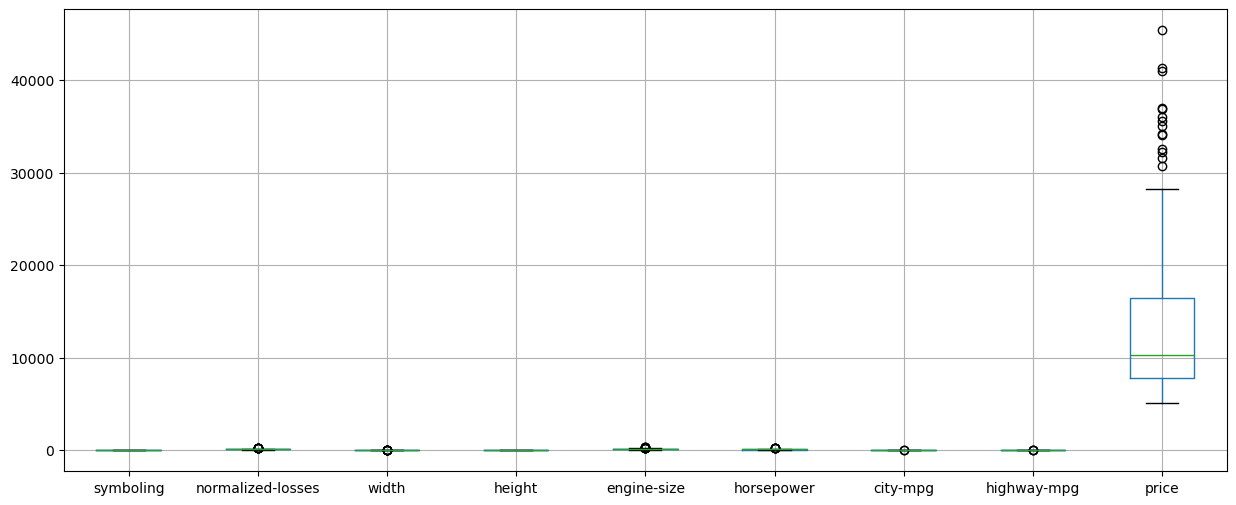

In [66]:
plt.figure(figsize=(15, 6))
df.boxplot()
plt.show()

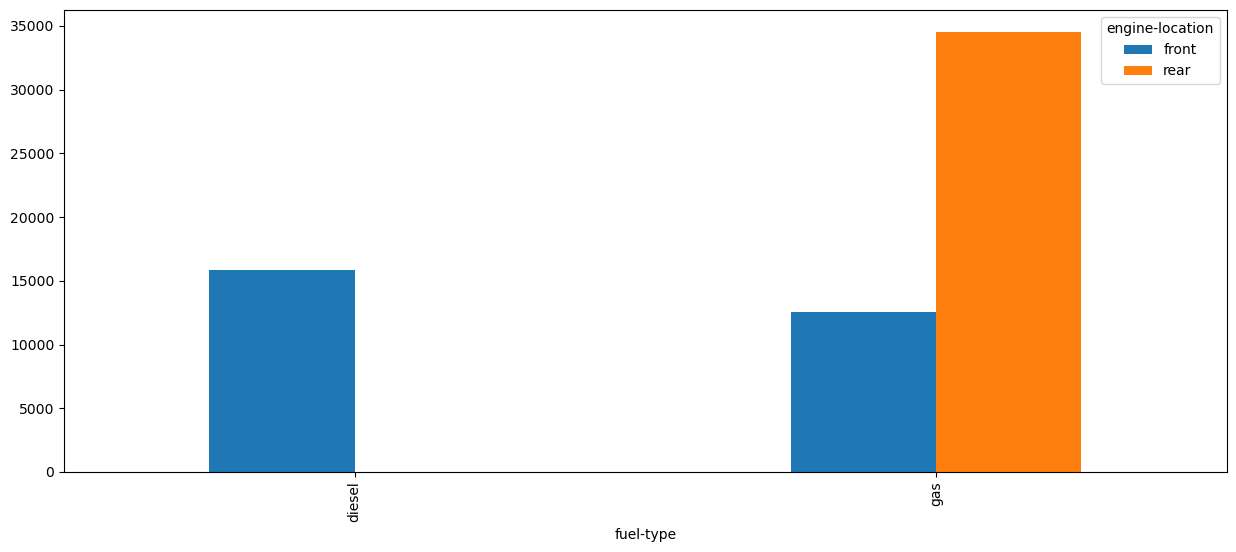

In [67]:
df.groupby(['fuel-type','engine-location'])['price'].mean().unstack().plot(kind='bar', figsize=(15, 6))
plt.show()

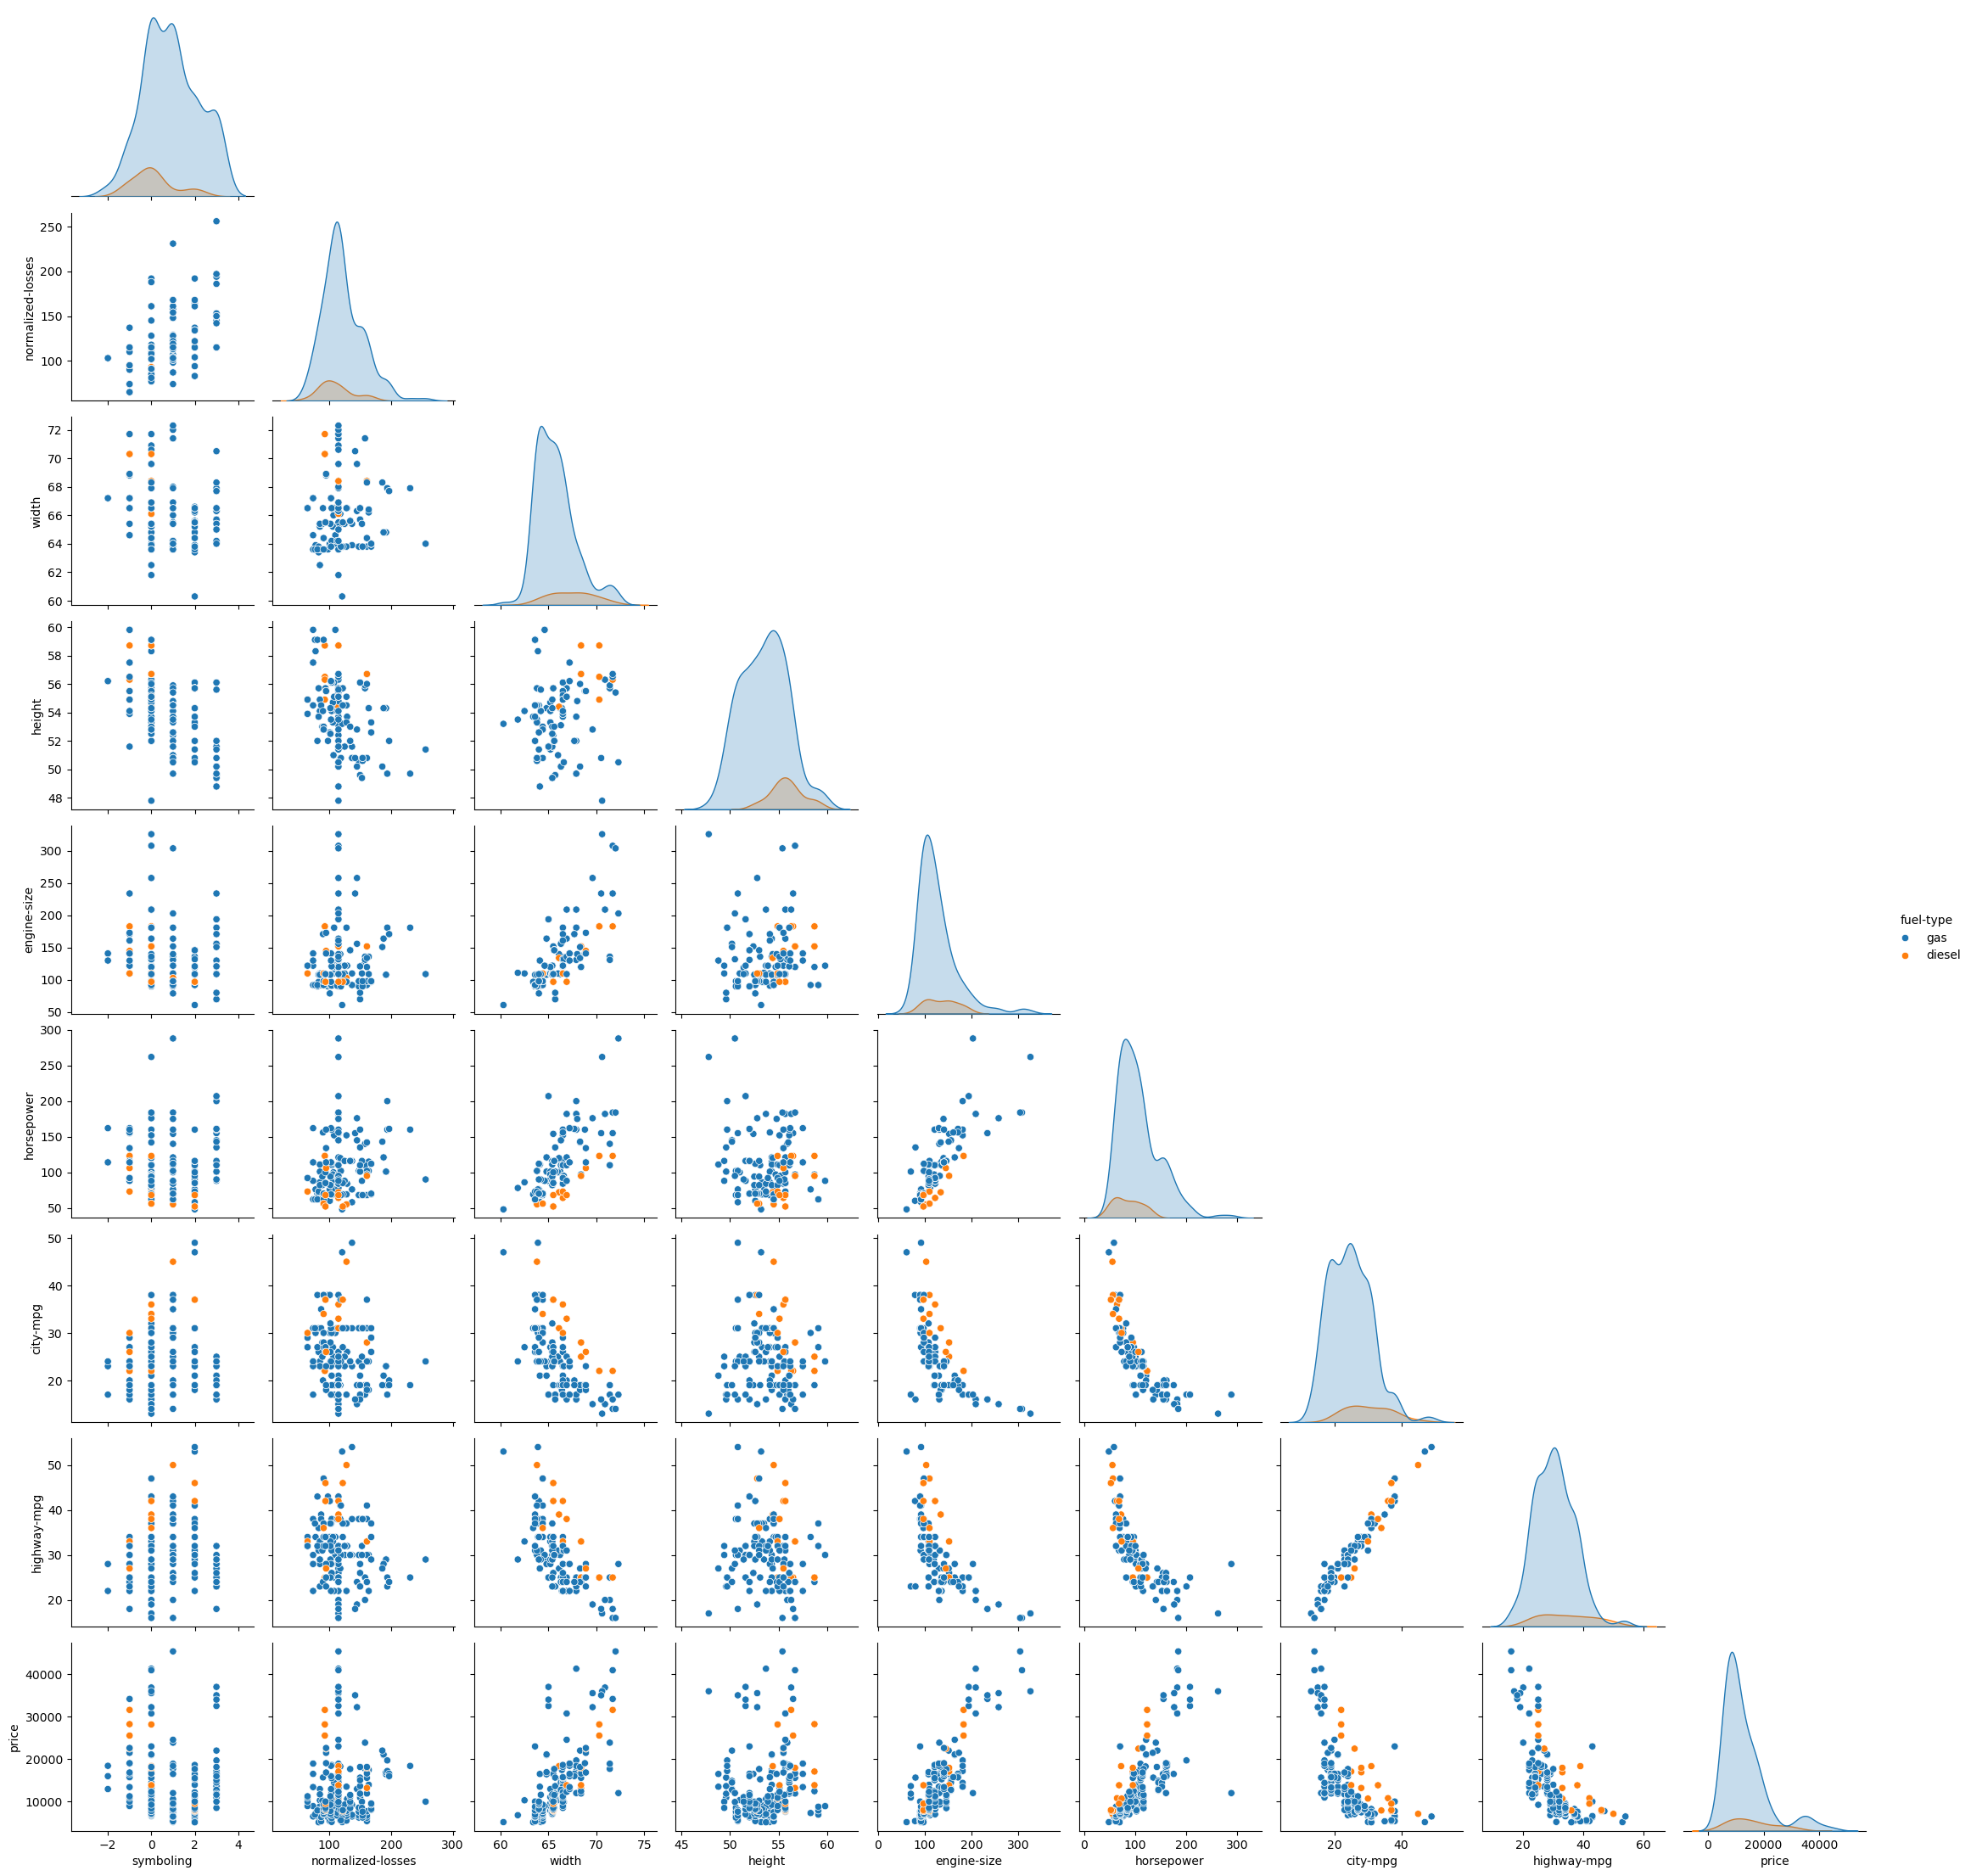

In [68]:
sns.pairplot(df, hue='fuel-type', diag_kind='kde', corner=True)
plt.show()

# Encoding

In [69]:
df['fuel-type'] = df['fuel-type'].map({'gas': 0, 'diesel': 1})

df['engine-location'] = df['engine-location'].map({'front': 0, 'rear': 1})

In [70]:
df = pd.get_dummies(
    df,
    columns=[
        'make',
        'body-style',
        'drive-wheels',
        'engine-type'
    ],
    drop_first=True,
    dtype=int
)

df.head()

,symboling,normalized-losses,fuel-type,engine-location,width,height,engine-size,horsepower,city-mpg,highway-mpg,...,body-style_sedan,body-style_wagon,drive-wheels_fwd,drive-wheels_rwd,engine-type_dohcv,engine-type_l,engine-type_ohc,engine-type_ohcf,engine-type_ohcv,engine-type_rotor
0,3,115,0,0,64.1,48.8,130,111,21,27,...,0,0,0,1,0,0,0,0,0,0
1,3,115,0,0,64.1,48.8,130,111,21,27,...,0,0,0,1,0,0,0,0,0,0
2,1,115,0,0,65.5,52.4,152,154,19,26,...,0,0,0,1,0,0,0,0,1,0
3,2,164,0,0,66.2,54.3,109,102,24,30,...,1,0,1,0,0,0,1,0,0,0
4,2,164,0,0,66.4,54.3,136,115,18,22,...,1,0,0,0,0,0,1,0,0,0


# Defining X and y

In [71]:
X=df.drop('price', axis=1)
y=df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [77]:
lr=LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print(f" Alpha: {i},Traning Accuracy: {lr.score(X_train, y_train)},Testing Accuracy: {lr.score(X_test, y_test)}")

 Alpha: engine-type,Traning Accuracy: 0.9607566270330499,Testing Accuracy: 0.7927312891899245


# Regularization Techniques

Regularization is a technique used to reduce **overfitting** by adding a penalty to the loss function. It helps improve the model's performance on unseen data.

---

# 1. L1 Regularization (Lasso Regression)

### Definition
L1 Regularization adds the **absolute value of the coefficients** to the loss function.

### Formula

\[
\text{Cost Function} = RSS + \lambda \sum |w|
\]

Where:
- RSS = Residual Sum of Squares
- λ = Regularization parameter
- w = Model coefficients

### Advantages
- Performs automatic feature selection.
- Sets some coefficients exactly to zero.
- Produces a simpler model.

### Disadvantages
- Can remove important features if λ is too large.

### Scikit-learn Code

```python
from sklearn.linear_model import Lasso

model = Lasso(alpha=0.1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
```

---

# 2. L2 Regularization (Ridge Regression)

### Definition
L2 Regularization adds the **square of the coefficients** to the loss function.

### Formula

\[
\text{Cost Function} = RSS + \lambda \sum w^2
\]

### Advantages
- Reduces overfitting.
- Handles multicollinearity effectively.
- Keeps all features.

### Disadvantages
- Does not perform feature selection.
- Coefficients become small but never exactly zero.

### Scikit-learn Code

```python
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
```

---

# 3. Elastic Net Regularization

### Definition
Elastic Net combines **L1 (Lasso)** and **L2 (Ridge)** regularization into a single model.

### Formula

\[
\text{Cost Function} = RSS + \lambda_1 \sum |w| + \lambda_2 \sum w^2
\]

### Advantages
- Performs feature selection.
- Handles correlated features effectively.
- Combines the strengths of both Ridge and Lasso.

### Disadvantages
- Requires tuning of two parameters.
- Slightly more complex than Ridge or Lasso.

### Scikit-learn Code

```python
from sklearn.linear_model import ElasticNet

model = ElasticNet(alpha=0.1, l1_ratio=0.5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
```

---

# Comparison

| Feature | Lasso (L1) | Ridge (L2) | Elastic Net |
|----------|------------|------------|-------------|
| Penalty | Absolute Value | Squared Value | L1 + L2 |
| Feature Selection | ✅ Yes | ❌ No | ✅ Yes |
| Coefficients Become Zero | ✅ Yes | ❌ No | ✅ Some |
| Handles Multicollinearity | Moderate | ✅ Yes | ✅ Best |
| Prevents Overfitting | ✅ | ✅ | ✅ |

# Lasso

In [78]:
for i in range(1,200):
    lasso = Lasso(alpha=i)
    lasso.fit(X_train, y_train)
    print(f" Alpha: {i},Traning Accuracy: {lasso.score(X_train, y_train)},Testing Accuracy: {lasso.score(X_test, y_test)}")

 Alpha: 1,Traning Accuracy: 0.9606565472750795,Testing Accuracy: 0.7948594630356951
 Alpha: 2,Traning Accuracy: 0.960389797441971,Testing Accuracy: 0.7951772077002074
 Alpha: 3,Traning Accuracy: 0.9600519567167098,Testing Accuracy: 0.7951964314308072
 Alpha: 4,Traning Accuracy: 0.9596313613948763,Testing Accuracy: 0.7949205179118258
 Alpha: 5,Traning Accuracy: 0.9590780533187173,Testing Accuracy: 0.7944763741685441
 Alpha: 6,Traning Accuracy: 0.9584137043443683,Testing Accuracy: 0.793719107423978
 Alpha: 7,Traning Accuracy: 0.9577799725120673,Testing Accuracy: 0.7930866407270555
 Alpha: 8,Traning Accuracy: 0.9571588751390935,Testing Accuracy: 0.7924983015391146
 Alpha: 9,Traning Accuracy: 0.9565047293262037,Testing Accuracy: 0.7915775524448843
 Alpha: 10,Traning Accuracy: 0.9558134680940302,Testing Accuracy: 0.7905683289897996
 Alpha: 11,Traning Accuracy: 0.9550716287775768,Testing Accuracy: 0.7903119901453854
 Alpha: 12,Traning Accuracy: 0.9542647577292555,Testing Accuracy: 0.79045070

# Ridge

In [ ]:
for i in range(1,200):
    rd = Ridge(alpha=i)
    rd.fit(X_train, y_train)
    print(f" Alpha: {i},Traning Accuracy: {rd.score(X_train, y_train)},Testing Accuracy: {rd.score(X_test, y_test)}")

 Alpha: 1,Traning Accuracy: 0.9405774510927549,Testing Accuracy: 0.7853636566446001
 Alpha: 2,Traning Accuracy: 0.9249003387383438,Testing Accuracy: 0.777332702559857
 Alpha: 3,Traning Accuracy: 0.9134911747463347,Testing Accuracy: 0.7715835158819743
 Alpha: 4,Traning Accuracy: 0.9046775541080841,Testing Accuracy: 0.7672012989490393
 Alpha: 5,Traning Accuracy: 0.8975693831845974,Testing Accuracy: 0.7636821713417373
 Alpha: 6,Traning Accuracy: 0.8916538669597404,Testing Accuracy: 0.7607466672121848
 Alpha: 7,Traning Accuracy: 0.8866124661620122,Testing Accuracy: 0.758228102300574
 Alpha: 8,Traning Accuracy: 0.8822354307933407,Testing Accuracy: 0.7560206582208033
 Alpha: 9,Traning Accuracy: 0.8783781979445819,Testing Accuracy: 0.754053680167299
 Alpha: 10,Traning Accuracy: 0.8749374124481281,Testing Accuracy: 0.7522780002793692
 Alpha: 11,Traning Accuracy: 0.8718369187136945,Testing Accuracy: 0.7506582000627195
 Alpha: 12,Traning Accuracy: 0.8690191661923183,Testing Accuracy: 0.749168005

# ElasticNet

In [ ]:
for i in range(1,200):
    el = ElasticNet(alpha=i)
    el.fit(X_train, y_train)
    print(f" Alpha: {i},Traning Accuracy: {el.score(X_train, y_train)},Testing Accuracy: {el.score(X_test, y_test)}")

 Alpha: 1,Traning Accuracy: 0.8133311883322216,Testing Accuracy: 0.7157957156036568
 Alpha: 2,Traning Accuracy: 0.7988041044350498,Testing Accuracy: 0.706769837516193
 Alpha: 3,Traning Accuracy: 0.7921516150144654,Testing Accuracy: 0.702970322788286
 Alpha: 4,Traning Accuracy: 0.788187286131362,Testing Accuracy: 0.7009750574471282
 Alpha: 5,Traning Accuracy: 0.7854837834905785,Testing Accuracy: 0.6998340323454459
 Alpha: 6,Traning Accuracy: 0.7834794753079012,Testing Accuracy: 0.6991697905098191
 Alpha: 7,Traning Accuracy: 0.7819066552132905,Testing Accuracy: 0.698801171307923
 Alpha: 8,Traning Accuracy: 0.7806207473688196,Testing Accuracy: 0.6986281851077
 Alpha: 9,Traning Accuracy: 0.7795364021157438,Testing Accuracy: 0.6985891747523021
 Alpha: 10,Traning Accuracy: 0.7785998694757333,Testing Accuracy: 0.6986456338147804
 Alpha: 11,Traning Accuracy: 0.7777754259375735,Testing Accuracy: 0.6987713662583155
 Alpha: 12,Traning Accuracy: 0.7770384191183175,Testing Accuracy: 0.6989481656950

# Final Model Build With ElasticNet

In [ ]:
el=ElasticNet(alpha=196)
el.fit(X_train, y_train)

,alpha,196
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


# Prediction

In [ ]:
y_pred = el.predict(X_test)
y_pred

array([26121.09235692, 16315.78483819, 11801.8097229 , 13128.63102203,
       20649.05099831,  7919.94997984,  8064.14024357,  8131.01709078,
       10402.35400064,  6749.12166223, 14912.62824813,  8467.72756212,
       15598.95383158, 11729.47044851, 37963.62330868,  6798.30906189,
        1670.35497379, 18365.30170456, 11894.09491921, 10381.03226742,
       11761.93455129, 21817.8498536 ,  8123.41995931,  5564.37206118,
        7091.609004  , 26097.5088067 , 15848.91122195, 15170.50566407,
        7803.96229206, 15292.11327193, 20607.187729  ,  7113.97961786,
        7338.96250821, 20057.39111417,  9910.94777832, 20571.08112768,
       11245.95693306,  7180.89826595,  6561.55256821, 18365.30170456,
        9813.67496883])

# Evaluation

In [80]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)  # sklearn >= 1.4
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R² Score :", r2)
print(f" Alpha: {i},Traning Accuracy: {el.score(X_train, y_train)},Testing Accuracy: {el.score(X_test, y_test)}")

MAE : 2641.200409952698
MSE : 16620476.143335393
RMSE : 4076.8218189338854
R² Score : 0.7927312891899245
 Alpha: 199,Traning Accuracy: 0.7502157414132867,Testing Accuracy: 0.71319879733574


## ✅ Conclusion

The regression model was successfully trained and evaluated using multiple performance metrics, including **Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score**. The training and testing accuracies indicate that the model has learned the relationship between the input features and the target variable effectively. Lower values of MAE, MSE, and RMSE indicate smaller prediction errors, while a higher R² Score demonstrates that the model explains a significant portion of the variance in the target variable. Overall, the model provides reliable predictions for used car prices and can be used to estimate vehicle prices based on their features. Further improvements can be achieved through feature engineering, hyperparameter tuning, and testing additional regression algorithms.